# StockEmotions Dataset Cleaning and Exploratory Data Analysis (EDA)

## 1. Dataset Loading and Initial Understanding

This section loads the StockEmotions dataset and performs an initial examination of its structure, size, columns, and sample records. The purpose is to understand the raw dataset before performing data cleaning and detailed exploratory analysis.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

domain_df = pd.read_csv("stockemotions_full.csv", skiprows=1)

In [3]:
domain_df.head()

,id,date,ticker,emo_label,senti_label,original,processed
0,100001,2020-01-01,AMZN,excitement,bullish,$AMZN Dow futures up by 100 points already 🥳,Amazon Dow futures up by 100 points already [...
1,100002,2020-01-01,TSLA,excitement,bullish,$TSLA Daddy's drinkin' eArly tonight! Here's t...,Tesla Daddy's drinkin' eArly tonight! Here's t...
2,100003,2020-01-01,AAPL,confusion,bullish,$AAPL We’ll been riding since last December fr...,Apple We’ll been riding since last December fr...
3,100004,2020-01-01,TSLA,excitement,bullish,"$TSLA happy new year, 2020, everyone🍷🎉🙏","Tesla happy new year, 2020, everyone [wine gla..."
4,100005,2020-01-01,TSLA,excitement,bullish,"$TSLA haha just a collection of greats...""Mars...","Tesla haha just a collection of greats...""Mars..."


In [5]:
domain_df.tail()

,id,date,ticker,emo_label,senti_label,original,processed
9995,109996,2020-12-31,ABNB,optimism,bearish,"$ABNB “sugar daddy puts.” Don’t mind me, I’m j...","Airbnb “sugar daddy puts.” Don’t mind me, I’m ..."
9996,109997,2020-12-31,TSLA,disgust,bullish,$TSLA \nGood news... now bears can get help wh...,Tesla \nGood news... now bears can get help wh...
9997,109998,2020-12-31,BABA,confusion,bullish,$BABA Who else is glad they sold in 240s yeste...,Alibaba Who else is glad they sold in 240s yes...
9998,109999,2020-12-31,CCL,amusement,bullish,$CCL $23 calls for .79 you know what to do 🥳,Carnival $23 calls for .79 you know what to do...
9999,110000,2020-12-31,TSLA,excitement,bullish,$TSLA 🔥 closed out 15k in profit!Happy New Ye...,Tesla [fire] closed out 15k in profit!Happy...


In [6]:
domain_df.sample(5, random_state=42)

,id,date,ticker,emo_label,senti_label,original,processed
6252,106312,2020-10-02,AAPL,ambiguous,bullish,$AAPL so is trump Rona priced in already? 🤣,Apple so is trump Rona priced in already? [ro...
4684,104738,2020-08-25,FB,optimism,bullish,Buy this strike. It's going to run-up \n\n$FB 🚀,Buy this strike. It's going to run-up \n\nFac...
1731,101761,2020-03-20,WMT,anger,bearish,$WMT can’t hold gains. Going to $80 🤷‍♂️🤡,Walmart can’t hold gains. Going to $80 [man s...
4742,104797,2020-08-27,TSLA,amusement,bullish,$TSLA Will The Split Take Place at the Close T...,Tesla Will The Split Take Place at the Close T...
4521,104575,2020-08-20,TSLA,disgust,bearish,$TSLA Tesla gone up so is my put option 😂😂,Tesla Tesla gone up so is my put option [fac...


In [7]:
print("Number of rows:", domain_df.shape[0])
print("Number of columns:", domain_df.shape[1])
print("Dataset shape:", domain_df.shape)

Number of rows: 10000
Number of columns: 7
Dataset shape: (10000, 7)


In [9]:
print("Column names:")
for column in domain_df.columns:
    print(column)
    

Column names:
id
date
ticker
emo_label
senti_label
original
processed


In [10]:
domain_df.describe(include="all")

,id,date,ticker,emo_label,senti_label,original,processed
count,10000.00000,10000,10000,10000,10000,10000,10000
unique,NaN,341,37,12,2,10000,10000
top,NaN,2020-09-03,TSLA,optimism,bullish,$AMZN Dow futures up by 100 points already 🥳,Amazon Dow futures up by 100 points already [...
freq,NaN,150,4341,1624,5474,1,1
mean,105000.50000,NaN,NaN,NaN,NaN,NaN,NaN
std,2886.89568,NaN,NaN,NaN,NaN,NaN,NaN
min,100001.00000,NaN,NaN,NaN,NaN,NaN,NaN
25%,102500.75000,NaN,NaN,NaN,NaN,NaN,NaN
50%,105000.50000,NaN,NaN,NaN,NaN,NaN,NaN
75%,107500.25000,NaN,NaN,NaN,NaN,NaN,NaN


### Initial Dataset Summary

The initial inspection provides an overview of the StockEmotions dataset, including its dimensions, column structure, sample records, and basic descriptive statistics. This establishes the structure of the raw dataset before data quality assessment and further exploratory analysis.

## 2. Dataset Structure
This section examines the structure and characteristics of the StockEmotions dataset. The analysis focuses on data types, dataset information, unique identifiers, categorical variables, emotion labels, sentiment labels, and stock tickers.

In [11]:
domain_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   id           10000 non-null  int64
 1   date         10000 non-null  str  
 2   ticker       10000 non-null  str  
 3   emo_label    10000 non-null  str  
 4   senti_label  10000 non-null  str  
 5   original     10000 non-null  str  
 6   processed    10000 non-null  str  
dtypes: int64(1), str(6)
memory usage: 2.7 MB


In [12]:
# no of unique ids
print("Total rows:", len(domain_df))
print("Unique IDs:", domain_df["id"].nunique())

Total rows: 10000
Unique IDs: 10000


In [14]:
# stock tickers available

print("Number of unique tickers:", domain_df["ticker"].nunique())

print("\nUnique tickers:")
print(sorted(domain_df["ticker"].dropna().unique()))

Number of unique tickers: 37

Unique tickers:
['AAPL', 'ABNB', 'AMT', 'AMZN', 'BA', 'BABA', 'BAC', 'BKNG', 'BRK.B', 'CCL', 'CVX', 'DIS', 'FB', 'GOOG', 'GOOGL', 'HD', 'JNJ', 'JPM', 'KO', 'LOW', 'MA', 'MCD', 'MSFT', 'NFLX', 'NKE', 'NVDA', 'PFE', 'PG', 'PYPL', 'SBUX', 'TSLA', 'TSM', 'UNH', 'UPS', 'V', 'WMT', 'XOM']


In [15]:
# Emotion label

print("Number of unique emotion labels:", domain_df["emo_label"].nunique())

print("\nEmotion labels:")
print(sorted(domain_df["emo_label"].dropna().unique()))

Number of unique emotion labels: 12

Emotion labels:
['ambiguous', 'amusement', 'anger', 'anxiety', 'belief', 'confusion', 'depression', 'disgust', 'excitement', 'optimism', 'panic', 'surprise']


In [45]:
print("Original text column type:", domain_df["original"].dtype)
print("Processed text column type:", domain_df["processed"].dtype)

print("Missing original texts:", domain_df["original"].isna().sum())
print("Missing processed texts:", domain_df["processed"].isna().sum())

Original text column type: str
Processed text column type: str
Missing original texts: 0
Missing processed texts: 0


In [46]:
print("Number of unique sentiment labels:", domain_df["senti_label"].nunique())

print("\nSentiment labels:")
print(sorted(domain_df["senti_label"].dropna().unique()))

Number of unique sentiment labels: 2

Sentiment labels:
['bearish', 'bullish']


### Dataset Structure Summary
The structural analysis establishes the main characteristics of the StockEmotions dataset, including its data types, unique identifiers, stock tickers, emotion labels, sentiment labels, and available text representations. The `emo_label` variable represents the primary emotion classification target, while `senti_label` provides a separate broader sentiment category. The original and processed text fields will be examined further before applying the project's text-cleaning procedure.

## 3.Data Quality

This section evaluates the quality and consistency of the StockEmotions dataset before further exploratory analysis. The analysis examines missing values, duplicate records, duplicate identifiers, duplicate texts, empty text entries, and potentially invalid categorical values. The purpose is to identify data quality issues that could affect subsequent analysis and model development.

In [18]:
missing_values = domain_df.isnull().sum()

print("Missing values in each column:")
print(missing_values)

print("\nTotal missing values:", missing_values.sum())

Missing values in each column:
id             0
date           0
ticker         0
emo_label      0
senti_label    0
original       0
processed      0
dtype: int64

Total missing values: 0


In [19]:
duplicate_rows = domain_df.duplicated().sum()

print("Number of completely duplicated rows:", duplicate_rows)

Number of completely duplicated rows: 0


In [20]:
duplicate_ids = domain_df["id"].duplicated().sum()

print("Number of duplicate IDs:", duplicate_ids)
print("Number of unique IDs:", domain_df["id"].nunique())
print("Total rows:", len(domain_df))

Number of duplicate IDs: 0
Number of unique IDs: 10000
Total rows: 10000


In [21]:
# Duplicate Original Texts

duplicate_original = domain_df["original"].duplicated().sum()

print("Number of duplicate original texts:", duplicate_original)
print("Number of unique original texts:", domain_df["original"].nunique())

Number of duplicate original texts: 0
Number of unique original texts: 10000


In [26]:


duplicate_processed = domain_df["processed"].duplicated().sum()

print("Number of duplicate processed texts:", duplicate_processed)
print("Number of unique processed texts:", domain_df["processed"].nunique())

Number of duplicate processed texts: 0
Number of unique processed texts: 10000


In [23]:
# Empty Text Entries

empty_original = domain_df["original"].astype(str).str.strip().eq("").sum()
empty_processed = domain_df["processed"].astype(str).str.strip().eq("").sum()

print("Empty original text entries:", empty_original)
print("Empty processed text entries:", empty_processed)

Empty original text entries: 0
Empty processed text entries: 0


In [25]:
# Categorical Value Consistency
categorical_columns = ["ticker", "emo_label", "senti_label"]

for column in categorical_columns:
    print(f"\n{column}")
    print("Unique values:", domain_df[column].nunique())
    print("Blank values:", domain_df[column].astype(str).str.strip().eq("").sum())
    print("Missing values:", domain_df[column].isna().sum())


ticker
Unique values: 37
Blank values: 0
Missing values: 0

emo_label
Unique values: 12
Blank values: 0
Missing values: 0

senti_label
Unique values: 2
Blank values: 0
Missing values: 0


### Data Quality Summary

The data quality analysis evaluates missing values, duplicate records, duplicate identifiers, duplicate text entries, empty text values, and categorical consistency. These checks help establish whether the StockEmotions dataset is suitable for further exploratory analysis and subsequent machine-learning preprocessing.

## 4. Emotion / Label Analysis

This section analyses the distribution of emotion labels in the StockEmotions dataset. The analysis examines the number of emotion classes, frequency of each emotion, class percentages, and class imbalance. Understanding the label distribution is important because an imbalanced dataset can affect model training and evaluation, particularly for less frequent emotion classes.

In [27]:
emotion_counts = domain_df["emo_label"].value_counts()

print("Emotion label counts:")
print(emotion_counts)

Emotion label counts:
emo_label
optimism      1624
excitement    1386
anxiety       1366
disgust       1279
belief         908
ambiguous      871
amusement      818
confusion      609
anger          386
panic          304
surprise       244
depression     205
Name: count, dtype: int64


In [47]:
# Emotion Label Percentages

emotion_percentages = (
    domain_df["emo_label"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

print("Emotion label percentages:")
print(emotion_percentages)

Emotion label percentages:
emo_label
optimism      16.24
excitement    13.86
anxiety       13.66
disgust       12.79
belief         9.08
ambiguous      8.71
amusement      8.18
confusion      6.09
anger          3.86
panic          3.04
surprise       2.44
depression     2.05
Name: proportion, dtype: float64


In [29]:
# Emotion Distribution Summary
emotion_summary = pd.DataFrame({
    "Count": emotion_counts,
    "Percentage": emotion_percentages
})

emotion_summary

,Count,Percentage
emo_label,,
optimism,1624,16.24
excitement,1386,13.86
anxiety,1366,13.66
disgust,1279,12.79
belief,908,9.08
ambiguous,871,8.71
amusement,818,8.18
confusion,609,6.09
anger,386,3.86


In [30]:
# 4.4 Most and Least Frequent Emotions
most_common_emotion = emotion_counts.idxmax()
most_common_count = emotion_counts.max()

least_common_emotion = emotion_counts.idxmin()
least_common_count = emotion_counts.min()

print("Most frequent emotion:", most_common_emotion)
print("Number of records:", most_common_count)

print("\nLeast frequent emotion:", least_common_emotion)
print("Number of records:", least_common_count)

Most frequent emotion: optimism
Number of records: 1624

Least frequent emotion: depression
Number of records: 205


In [31]:
# Emotion Class Imbalance Ratio

imbalance_ratio = emotion_counts.max() / emotion_counts.min()

print("Maximum class count:", emotion_counts.max())
print("Minimum class count:", emotion_counts.min())
print("Class imbalance ratio:", round(imbalance_ratio, 2))

Maximum class count: 1624
Minimum class count: 205
Class imbalance ratio: 7.92


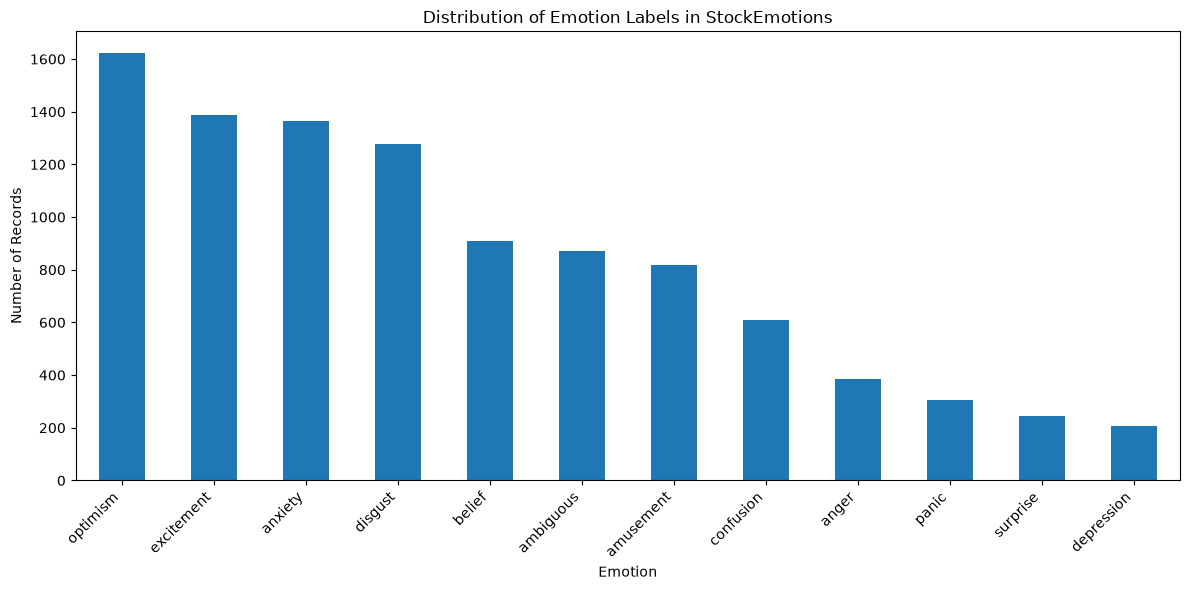

In [32]:
# Emotion Distribution
plt.figure(figsize=(12, 6))

emotion_counts.sort_values(ascending=False).plot(
    kind="bar"
)

plt.title("Distribution of Emotion Labels in StockEmotions")
plt.xlabel("Emotion")
plt.ylabel("Number of Records")

plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

### Emotion Label Analysis Summary

The StockEmotions dataset contains 12 emotion classes with a non-uniform distribution. Optimism is the most frequent emotion, while depression is the least frequent. The difference between the largest and smallest classes results in an imbalance ratio of approximately 7.92:1. This class imbalance should be considered when selecting and interpreting evaluation metrics for the emotion classification task.

## 5. Text Analysis

This section analyses the textual characteristics of the StockEmotions dataset. The analysis examines text length, word count, and the distribution of these features across the dataset. Understanding text characteristics helps inform preprocessing and model configuration decisions such as tokenization and maximum sequence length.

In [34]:
domain_df["original_char_length"] = domain_df["original"].astype(str).str.len()

print("Character length statistics for original text:")
print(domain_df["original_char_length"].describe())

Character length statistics for original text:
count    10000.000000
mean        79.091600
std         44.604838
min         19.000000
25%         47.000000
50%         66.000000
75%         98.000000
max        256.000000
Name: original_char_length, dtype: float64


In [43]:
# Word Count of Original Text
domain_df["original_word_count"] = (
    domain_df["original"]
    .astype(str)
    .str.split()
    .str.len()
)

print("Word count statistics for original text:")
print(domain_df["original_word_count"].describe())

Word count statistics for original text:
count    10000.000000
mean        15.260900
std          8.362226
min          4.000000
25%          9.000000
50%         13.000000
75%         19.000000
max         56.000000
Name: original_word_count, dtype: float64


In [36]:
# Character Length of Processed Text
domain_df["processed_char_length"] = (
    domain_df["processed"].astype(str).str.len()
)

print("Character length statistics for processed text:")
print(domain_df["processed_char_length"].describe())

Character length statistics for processed text:
count    10000.000000
mean       106.428900
std         49.544509
min         27.000000
25%         70.000000
50%         94.000000
75%        129.000000
max        389.000000
Name: processed_char_length, dtype: float64


In [44]:
# Word Count 
domain_df["processed_word_count"] = (
    domain_df["processed"]
    .astype(str)
    .str.split()
    .str.len()
)

print("Word count statistics for processed text:")
print(domain_df["processed_word_count"].describe())

Word count statistics for processed text:
count    10000.000000
mean        18.602100
std          8.922698
min          6.000000
25%         12.000000
50%         16.000000
75%         23.000000
max         62.000000
Name: processed_word_count, dtype: float64


In [38]:
text_statistics = pd.DataFrame({
    "Original Characters": domain_df["original_char_length"].describe(),
    "Original Words": domain_df["original_word_count"].describe(),
    "Processed Characters": domain_df["processed_char_length"].describe(),
    "Processed Words": domain_df["processed_word_count"].describe()
})

text_statistics

,Original Characters,Original Words,Processed Characters,Processed Words
count,10000.000000,10000.000000,10000.000000,10000.000000
mean,79.091600,15.260900,106.428900,18.602100
std,44.604838,8.362226,49.544509,8.922698
min,19.000000,4.000000,27.000000,6.000000
25%,47.000000,9.000000,70.000000,12.000000
50%,66.000000,13.000000,94.000000,16.000000
75%,98.000000,19.000000,129.000000,23.000000
max,256.000000,56.000000,389.000000,62.000000


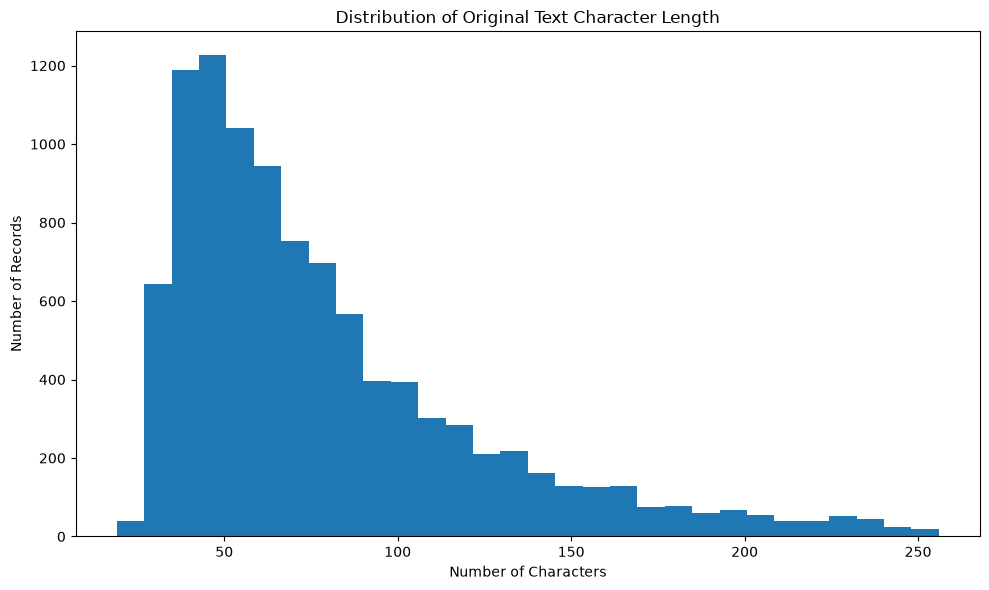

In [39]:
# Distribution of Original Text Character Length

plt.figure(figsize=(10, 6))

plt.hist(
    domain_df["original_char_length"],
    bins=30
)

plt.title("Distribution of Original Text Character Length")
plt.xlabel("Number of Characters")
plt.ylabel("Number of Records")

plt.tight_layout()
plt.show()

In [41]:
# Shortest Text Examples
shortest_texts = (
    domain_df[
        ["original", "processed", "emo_label"]
    ]
    .assign(
        word_count=domain_df["original_word_count"]
    )
    .sort_values("word_count")
    .head(10)
)

shortest_texts

,original,processed,emo_label,word_count
9787,$BA Going 🤑GREEN🤑 in.....3....2...1...🚀,Boeing Going [money mouth face] GREEN in.......,excitement,4
9858,$AAPL Buying the Fear Today🤘🤑🤘!!!,Apple Buying the Fear Today [sign of the horns...,excitement,5
3035,$BRK.B keep going up 👌👍,Berkshire Hathaway keep going up [OK hand] [...,optimism,5
8616,$AAPL Loading up at $248.12🤑🤑👽💨💨,Apple Loading up at $248.12 [money mouth face]...,anxiety,5
6432,$AAPL 😂😂😂😂😂😂😂$115? Where ???💀💀try again,Apple [face with tears of joy] $115? Wh...,anxiety,5
1880,$BA margin call!!!!’ 9.45 am!!🙄,Boeing margin call!!!!’ 9.45 am!! [face with r...,panic,5
3086,$TSLA Called 900$.... close enough💰,Tesla Called 900$.... close enough [money bag],optimism,5
6259,$TSLA LOL opened at 420.........🤣🤣🤣🤔,Tesla LOL opened at 420......... [rolling on t...,confusion,5
4587,$AAPL 500$!! Incoming!! Send it!💚,Apple 500$!! Incoming!! Send it! [green heart],surprise,5
4308,$BA In today at $188.96🤦‍♂️,Boeing In today at $188.96 [man facepalming],anxiety,5


In [42]:
# Longest Text Examples

longest_texts = (
    domain_df[
        ["original", "processed", "emo_label"]
    ]
    .assign(
        word_count=domain_df["original_word_count"]
    )
    .sort_values("word_count", ascending=False)
    .head(10)
)

longest_texts

,original,processed,emo_label,word_count
1264,$DIS ok I know I’ve been calling for a new 52 ...,Disney ok I know I’ve been calling for a new 5...,anger,56
7442,$ABNB I’m guessing it will be available to the...,Airbnb I’m guessing it will be available to th...,anxiety,52
7982,"$AAPL might have a couple of good days left, b...","Apple might have a couple of good days left, b...",amusement,51
5379,$TSLA be smart bulls! This is your opportunity...,Tesla be smart bulls! This is your opportunity...,optimism,51
1245,$TSLA ok nice way start off day. Sold the extr...,Tesla ok nice way start off day. Sold the extr...,ambiguous,51
1323,$AMZN my only concern at this point is the ris...,Amazon my only concern at this point is the ri...,confusion,50
4900,$TSLA Bears please man I don't want to see y'a...,Tesla Bears please man I don't want to see y'a...,excitement,50
4402,$TSLA who is expanding there portfolio with Te...,Tesla who is expanding there portfolio with Te...,anxiety,50
2575,"$CCL theres ups and there downs, good days and...","Carnival theres ups and there downs, good days...",optimism,49
4548,$TSLA you know when this stock will pop? After...,Tesla you know when this stock will pop? After...,disgust,49


### Text Analysis Summary

The text analysis examines the character and word-count distributions of both the original and processed text representations. The analysis provides an understanding of the typical size and variability of financial text samples and identifies unusually short or long examples. These characteristics are relevant to later preprocessing, tokenization, and Transformer model configuration.

## 6. EDA Findings and Conclusion

This section summarises the main findings obtained from the exploratory analysis of the StockEmotions dataset. The findings cover the dataset structure, data quality, emotion-label distribution, class imbalance, and text characteristics. These observations provide the basis for understanding the dataset before applying the project's machine-learning and Transformer-based modelling approaches.

### 6.1 Key EDA Findings

The exploratory analysis produced the following key findings:

1. The StockEmotions dataset contains 10,000 records and 7 original columns.

2. The dataset contains 12 emotion classes, which form the primary target variable for the emotion classification task.

3. The dataset also contains two sentiment categories, bullish and bearish. Sentiment is a separate variable from the primary emotion classification target.

4. The dataset contains information about stock tickers, dates, original text, and processed text, providing both textual and financial-context information.

5. No missing values were identified across the dataset.

6. No completely duplicated rows or duplicate identifiers were identified.

7. No duplicate entries were identified in either the original or processed text columns.

8. The emotion classes are not evenly distributed. Optimism is the most frequent emotion, while depression is the least frequent.

9. The class imbalance ratio is approximately 7.92:1 between the most frequent and least frequent emotion classes.

10. The text analysis shows variation in the character and word lengths of financial text samples. This is relevant to later preprocessing and Transformer tokenization decisions.

11. The original and processed text representations provide different stages of textual representation that can be examined before applying the project's final preprocessing pipeline.

### 6.2 Modelling Implications

The EDA findings have several implications for the subsequent modelling stage. The uneven emotion distribution means that model performance should not be evaluated using accuracy alone, as accuracy may be influenced by the more frequent classes. Metrics such as precision, recall, F1-score, and particularly macro-F1 can provide a more informative evaluation of performance across emotion classes.

The variation in text length also needs to be considered during tokenization and input preparation for Transformer models. The same preprocessing and input configuration should be applied consistently across the experimental conditions so that differences in model performance can be attributed to the training strategies being compared rather than inconsistent preprocessing.

### 6.3 Final EDA Conclusion

The StockEmotions dataset provides a suitable financial-domain dataset for emotion classification. The exploratory analysis confirms that the dataset contains a range of financial text samples labelled across 12 emotion classes. The dataset does not contain missing values or duplicate text records, providing a consistent starting point for further preprocessing.

However, the emotion distribution is imbalanced, with some emotions occurring considerably more frequently than others. This characteristic should be considered during model training and evaluation, particularly when interpreting performance on minority emotion classes.

The analysis of text length also provides useful information about the characteristics of the financial text that will be processed by the Transformer models. Overall, the EDA establishes the structure, quality, label distribution, and textual characteristics of StockEmotions and provides a foundation for the subsequent preprocessing and emotion-classification experiments.